In [62]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import yfinance as yf
from datetime import datetime, timedelta

In [63]:
ticker = "GOOG"
start_date = '2024-1-1'

In [64]:
def import_stock_data(ticker, start='2010-1-1'):
    # Define a Dataframe for storing your stock data
    data = pd.DataFrame()
    
    # Using Yahoo Finance to get stock data
    stock = yf.Ticker(ticker)
    data = stock.history(start=start)
        
    return data

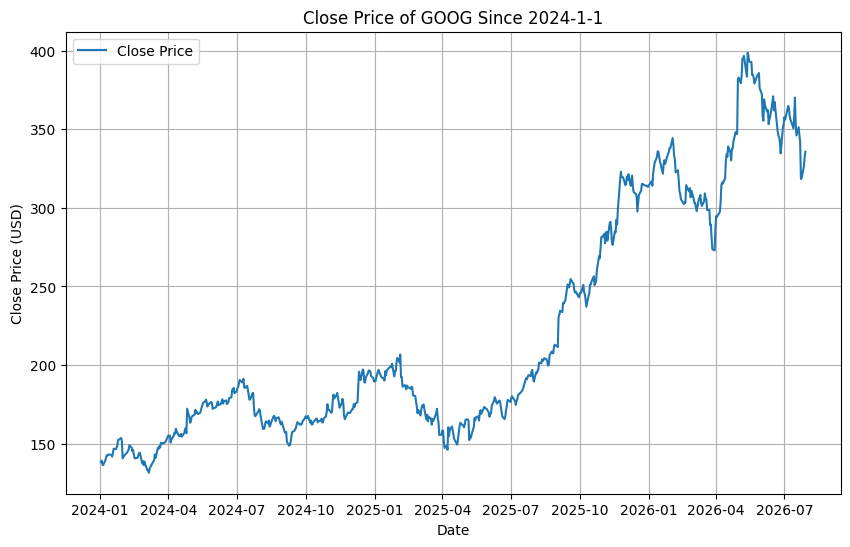

In [65]:
data = import_stock_data(ticker, start = start_date)

# Plot the close price
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Close Price')
plt.title(f'Close Price of {ticker} Since {start_date}')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
def log_returns(stock_data):

    # Assuming you're interested in the 'Close' prices
    log_returns = np.log(1 + stock_data['Close'].pct_change())
    log_returns = log_returns[1:]
    
    return log_returns

Date
2026-07-23 00:00:00-04:00   -0.071428
2026-07-24 00:00:00-04:00    0.002353
2026-07-27 00:00:00-04:00    0.023171
2026-07-28 00:00:00-04:00    0.018296
2026-07-29 00:00:00-04:00    0.009456
Name: Close, dtype: float64


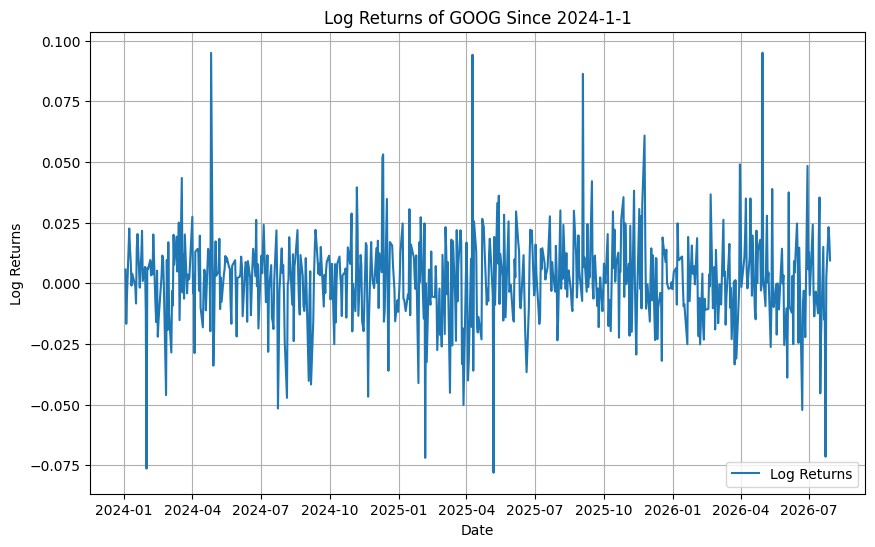

In [67]:
log_return = log_returns(data)

print(log_return.tail())

# Plot the log returns
plt.figure(figsize=(10, 6))
plt.plot(log_return, label='Log Returns')
plt.title(f'Log Returns of {ticker} Since {start_date}')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend()
plt.grid(True)
plt.show()

In [68]:
def volatility_calc(lr):
    daily_volatility = np.std(lr)
    return daily_volatility

In [69]:
# Test
log_return = log_returns(data)
print(volatility_calc(log_return))

0.019077227208189933


In [70]:
num_simulations = 100000
num_days = 2

# Get the closing price for the last day of the stock data
last_price = data['Close'].iloc[-1]

In [71]:
def run_monteCarlo(num_simulations, num_days, last_price, log_return):
    # Calculate daily volatility
    daily_vol = volatility_calc(log_return)
    
    # Initialize a list to store all simulation results
    all_simulations = []
    
    for x in range(num_simulations):
        price_series = [last_price]
        
        for y in range(1, num_days):
            price = price_series[-1] * (1 + np.random.normal(0, daily_vol))
            price_series.append(price)
        
        all_simulations.append(price_series)
    
    # Convert the list of simulations into a DataFrame all at once
    simulation_df = pd.DataFrame(all_simulations).transpose()
    
    return simulation_df

In [72]:
# Test
log_return = log_returns(data)
simulation_df = run_monteCarlo(num_simulations, num_days, last_price, log_return)

simulation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
0,335.760010,335.760010,335.760010,335.760010,335.760010,335.760010,335.760010,335.760010,335.760010,335.760010,...,335.760010,335.760010,335.76001,335.760010,335.760010,335.760010,335.760010,335.760010,335.76001,335.760010
1,329.418197,318.646319,325.687709,339.566543,343.806618,332.251255,344.778519,342.213582,341.428197,319.959325,...,339.588544,326.083122,343.48887,330.466482,340.902729,340.556897,332.674405,353.153857,332.30949,321.733132


Text(0, 0.5, 'Price')

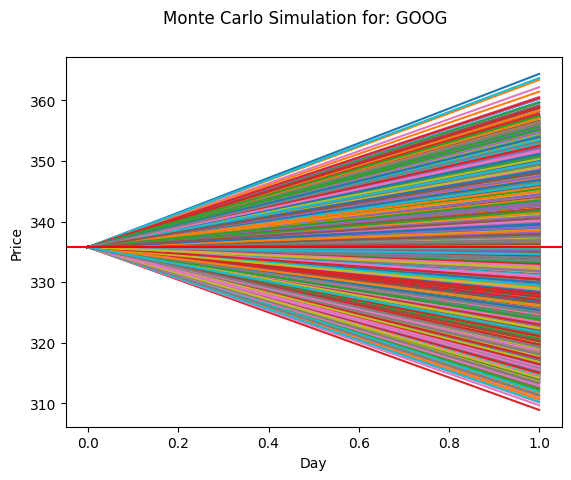

In [73]:
simulation_df.plot(legend=False)
plt.suptitle(f'Monte Carlo Simulation for: {ticker}')
plt.axhline(y = last_price, color = 'r', linestyle= '-')
plt.xlabel('Day')
plt.ylabel('Price')

In [74]:
# Extract the prices for the end of the second day (which is the last row in this case)
day_2_prices = simulation_df.iloc[-1]  # Last row since num_days = 2

# Calculate the 95% confidence interval
lower_bound = np.percentile(day_2_prices, 2.5)
upper_bound = np.percentile(day_2_prices, 97.5)

# Calculate the mean (expected) price
mean_price = np.mean(day_2_prices)

# Print the results
print(f"The expected price for 2 days later is: {mean_price}")
print(f"The 95% confidence interval for the price 2 days later is: ({lower_bound}, {upper_bound})")

The expected price for 2 days later is: 335.78481460061386
The 95% confidence interval for the price 2 days later is: (323.24702464174777, 348.3950207866263)


In [75]:
# Calculate the 98% confidence interval
# For a 98% CI, we look for the 1st and 99th percentiles
lower_bound = np.percentile(day_2_prices, 1)
upper_bound = np.percentile(day_2_prices, 99)

# Calculate the mean (expected) price
mean_price = np.mean(day_2_prices)

# Print the results
print(f"The expected price for 2 days later is: {mean_price}")
print(f"The 98% confidence interval for the price 2 days later is: ({lower_bound}, {upper_bound})")

The expected price for 2 days later is: 335.78481460061386
The 98% confidence interval for the price 2 days later is: (320.9076985134882, 350.76338730396947)


In [76]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import yfinance as yf
from datetime import datetime, timedelta

In [77]:
class MonteCarlo():
    
    def __init__(self , ticker , start_date , end_date , days , sim):
        self.ticker = ticker
        self.start = start_date
        self.end = end_date
        self.noOfSimulations = sim
        self.noOfDays = days
        
        self.import_stock_data()
        self.calc_log_returns()
        self.volatility_calc()
        self.run_monteCarlo()
    
    def import_stock_data(self):
        self.data = pd.DataFrame()
    
        # Using Yahoo Finance to get stock data
        stock = yf.Ticker(ticker)
        self.data = stock.history(start=self.start)

    def calc_log_returns(self):

        # Assuming you're interested in the 'Close' prices
        self.log_returns = np.log(1 + self.data['Close'].pct_change())
        self.log_returns = self.log_returns[1:]

    def volatility_calc(self):
        self.daily_volatility = np.std(self.log_returns)
    
    def run_monteCarlo(self):
        # Get the last days stock price
        last_price = self.data['Close'].iloc[-1]
        self.last_price = last_price
        
        # Initialize a list to store all simulation results
        all_simulations = []

        for x in range(self.noOfSimulations):
            price_series = [last_price]

            for y in range(1, self.noOfDays):
                price = price_series[-1] * (1 + np.random.normal(0, self.daily_volatility))
                price_series.append(price)

            all_simulations.append(price_series)

        # Convert the list of simulations into a DataFrame all at once
        self.simulation_df = pd.DataFrame(all_simulations).transpose()
                
    def results(self):
        # Extract the prices for the end of the second day (which is the last row in this case)
        prices = self.simulation_df.iloc[-1]  # Last row since num_days = 2

        # Calculate the 95% confidence interval
        lower_bound = np.percentile(prices, 2.5)
        upper_bound = np.percentile(prices, 97.5)

        # Calculate the mean (expected) price
        mean_price = np.mean(prices)

        # Print the results
        print(f"{self.ticker} expected price for {self.noOfDays} days later is: {mean_price}")
        print(f"{self.ticker} 95% confidence interval for the price {self.noOfDays} days later is: ({lower_bound}, {upper_bound})")
        print("\n")
        
    def plot(self):
        self.simulation_df.plot(legend=False)
        plt.suptitle(f'Monte Carlo Simulation for: {self.ticker}')
        plt.axhline(y = self.last_price, color = 'r', linestyle= '-')
        plt.xlabel('Day')
        plt.ylabel('Price')

In [78]:
# Define your list of tickers
tickers = ["HSCL.NS", "BHEL.NS", "JPASSOCIAT.NS" , "ZOMATO.NS"]
end_date = datetime.now().strftime('%Y-%m-%d')  # Today's date in YYYY-MM-DD format
start_date = (datetime.now() - timedelta(days=2*365)).strftime('%Y-%m-%d')  # Two years before today
# Initialize a dictionary to hold your results
results = {}
# Loop through each ticker and run the simulation
for ticker in tickers:
    try:
        simulation = MonteCarlo(ticker, start_date, end_date, 5, 1000)
        simulation.results()
    except Exception as e:
        print(f"Skipping {ticker}: {e}\n")

HSCL.NS expected price for 5 days later is: nan
HSCL.NS 95% confidence interval for the price 5 days later is: (nan, nan)




/var/folders/5x/08n_sbvx0h78tljz4bwg7wtc0000gn/T/ipykernel_6118/2686596458.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.log_returns = np.log(1 + self.data['Close'].pct_change())
/var/folders/5x/08n_sbvx0h78tljz4bwg7wtc0000gn/T/ipykernel_6118/2686596458.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.log_returns = np.log(1 + self.data['Close'].pct_change())
$JPASSOCIAT.NS: possibly delisted; no timezone found
$ZOMATO.NS: possibly delisted; no timezone found


BHEL.NS expected price for 5 days later is: nan
BHEL.NS 95% confidence interval for the price 5 days later is: (nan, nan)


Skipping JPASSOCIAT.NS: single positional indexer is out-of-bounds

Skipping ZOMATO.NS: single positional indexer is out-of-bounds



In [79]:
# Quick sanity check with well-known, currently active tickers
test_tickers = ["AAPL", "MSFT", "TSLA", "NVDA"]

for ticker in test_tickers:
    simulation = MonteCarlo(ticker, start_date, end_date, 5, 1000)
    simulation.results()

AAPL expected price for 5 days later is: 337.7806515997298
AAPL 95% confidence interval for the price 5 days later is: (315.2306740111935, 361.2577157790723)


MSFT expected price for 5 days later is: 390.6777946029916
MSFT 95% confidence interval for the price 5 days later is: (366.30941005146497, 415.6608815022804)


TSLA expected price for 5 days later is: 297.09547914864754
TSLA 95% confidence interval for the price 5 days later is: (254.69049237488204, 345.19499496297317)


NVDA expected price for 5 days later is: 190.382814231548
NVDA 95% confidence interval for the price 5 days later is: (168.09792277900218, 214.79668026795792)


